# Explanation Notebook for ScenarioModel6
*Model Type:* **KNN**
*User:* UserKNN (Expertise: Intermediate, Formats: [plainText, table, visual], Details: medium, Purpose: general)
*Explanation Method:* ICE


## Training the KNN Model
We train a **KNN** model on the provided dataset.


In [1]:
import warnings; warnings.filterwarnings('ignore')
!pip install -q scikit-learn pandas matplotlib
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"data/breast_cancer.csv")
y = df['target']
X = df.drop(columns=['target']).values
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
    print('[Info] Used stratified split to preserve class proportions in train/test.')
except Exception:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    print('[Info] Used non-stratified split (stratification not applicable).')
class Dummy: pass
data = Dummy(); data.feature_names = list(df.drop(columns=['target']).columns)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
base_model = KNeighborsClassifier(n_neighbors=5)
model = make_pipeline(StandardScaler(), base_model)
print('[Info] Normalization enabled by training policy: using StandardScaler in a pipeline.')
model.fit(X_train, y_train)
print('Accuracy: KNN = ' + format(model.score(X_test, y_test), '.2f'))


[Info] Used stratified split to preserve class proportions in train/test.
[Info] Normalization enabled by training policy: using StandardScaler in a pipeline.
Accuracy: KNN = 0.96


## Explaining the model using ICE
Individual Conditional Expectation (ICE) plots show prediction trajectories per instance for a feature.



[ICE overview]
ICE shows how the prediction changes for individual instances as one feature varies.

[Plain-text explanation]
This explanation summarizes the model's behaviour at a global level.
Feature under analysis: Mean Radius
How to read this explanation: ICE reveals whether different instances react similarly or differently when the selected feature changes.
Large separation between lines suggests heterogeneous behaviour across instances.
Number of sampled instances: 10

[Tabular explanation]
Summary columns: start/end predictions, minimum/maximum prediction, and total variation for each sampled instance.


,Instance,Feature,StartPrediction,EndPrediction,MinPrediction,MaxPrediction,Variation
0,0,Mean Radius,0.2,0.0,0.0,0.2,0.2
1,1,Mean Radius,0.0,0.0,0.0,0.0,0.0
2,2,Mean Radius,0.0,0.0,0.0,0.0,0.0
3,3,Mean Radius,1.0,0.4,0.4,1.0,0.6
4,4,Mean Radius,0.0,0.0,0.0,0.0,0.0
5,5,Mean Radius,1.0,0.8,0.8,1.0,0.2
6,6,Mean Radius,0.0,0.0,0.0,0.0,0.0
7,7,Mean Radius,1.0,0.8,0.8,1.0,0.2
8,8,Mean Radius,1.0,1.0,1.0,1.0,0.0
9,9,Mean Radius,0.0,0.0,0.0,0.0,0.0



[Visual explanation]
How to read the plot: line separation indicates whether the feature effect is stable across instances or varies from case to case.


<Figure size 800x460 with 0 Axes>

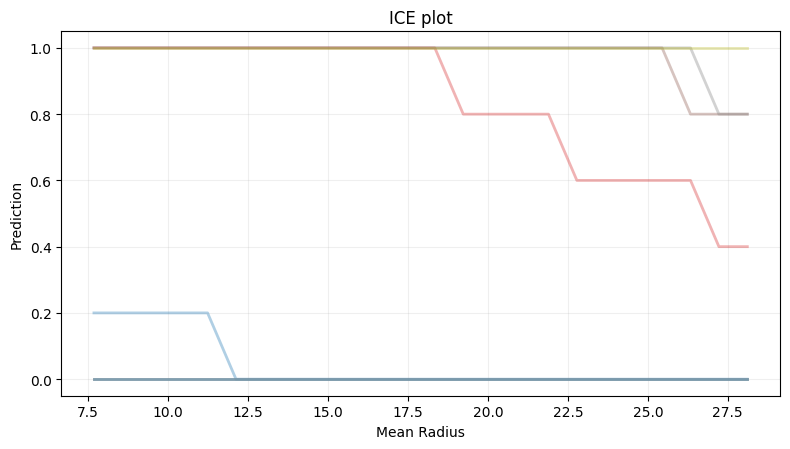

In [2]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt

def _get_feature_names():
    try:
        names = list(getattr(data, 'feature_names', []))
        if names and len(names) == X_train.shape[1]:
            return names
    except Exception:
        pass
    if 'df' in globals():
        cols = [c for c in df.columns if c.lower() not in ('label','target','y')]
        if len(cols) == X_train.shape[1]:
            return cols
    return [f'f{j}' for j in range(X_train.shape[1])]

RAW_NAMES = _get_feature_names()
def _humanize(name):
    s = name.replace('_',' ').strip()
    s = re.sub(r'(?<!^)(?=[A-Z])',' ', s)
    s = re.sub(r'\s+',' ', s).strip()
    return ' '.join([w.upper() if w.lower() in {'svm','pdp','ice','api','url'} else w.capitalize() for w in s.split(' ')])
HUMAN = [_humanize(n) for n in RAW_NAMES]

max_display = 6
table_rows = 10
curve_resolution = 24
ice_instances = 10
metric_digits = 4
figure_height = 4.6
line_width = 2.0
pdp_sample_rows = 8
ice_detailed_instances = 3
sampled_curve_points = 7
print('\n[ICE overview]')
print('ICE shows how the prediction changes for individual instances as one feature varies.')
feat_idx = 0
xs = X_train[:, feat_idx]
grid = np.linspace(np.min(xs), np.max(xs), num=curve_resolution)
n_instances = min(ice_instances, X_test.shape[0])
summary_rows = []
point_rows = []
sample_idx = np.unique(np.linspace(0, len(grid)-1, num=min(sampled_curve_points, len(grid))).astype(int))
for inst in range(n_instances):
    base = X_test[inst].copy()
    preds = []
    for g in grid:
        x = base.copy()
        x[feat_idx] = g
        if hasattr(model, 'predict_proba'):
            preds.append(float(model.predict_proba([x])[0][1]))
        else:
            preds.append(float(model.predict([x])[0]))
    pred_arr = np.array(preds, dtype=float)
    summary_rows.append({'Instance': inst, 'Feature': HUMAN[feat_idx], 'StartPrediction': float(pred_arr[0]), 'EndPrediction': float(pred_arr[-1]), 'MinPrediction': float(pred_arr.min()), 'MaxPrediction': float(pred_arr.max()), 'Variation': float(pred_arr.max() - pred_arr.min())})
    if inst < ice_detailed_instances:
        for pos in sample_idx:
            point_rows.append({'Instance': inst, 'FeatureValue': float(grid[pos]), 'Prediction': float(pred_arr[pos])})
df_ice_summary = pd.DataFrame(summary_rows)
df_ice_points = pd.DataFrame(point_rows)
print('\n[Plain-text explanation]')
print("This explanation summarizes the model's behaviour at a global level.")
print('Feature under analysis: ' + HUMAN[feat_idx])
print('How to read this explanation: ICE reveals whether different instances react similarly or differently when the selected feature changes.')
print('Large separation between lines suggests heterogeneous behaviour across instances.')
print('Number of sampled instances: ' + str(n_instances))
print('\n[Tabular explanation]')
print('Summary columns: start/end predictions, minimum/maximum prediction, and total variation for each sampled instance.')
display(df_ice_summary[['Instance','Feature','StartPrediction','EndPrediction','MinPrediction','MaxPrediction','Variation']].head(table_rows))
print('\n[Visual explanation]')
print('How to read the plot: line separation indicates whether the feature effect is stable across instances or varies from case to case.')
plt.figure(figsize=(8, figure_height))
detail_alpha = 0.55 if n_instances <= 8 else 0.35
for inst in range(n_instances):
    row = df_ice_points[df_ice_points['Instance'] == inst]
for idx in range(n_instances):
    # plotting from recomputed summaries is easier using the original loop again
    pass
plt.figure(figsize=(8, figure_height))
for inst in range(n_instances):
    base = X_test[inst].copy()
    preds = []
    for g in grid:
        x = base.copy()
        x[feat_idx] = g
        if hasattr(model, 'predict_proba'):
            preds.append(float(model.predict_proba([x])[0][1]))
        else:
            preds.append(float(model.predict([x])[0]))
    plt.plot(grid, preds, linewidth=line_width, alpha=0.35 if n_instances > 8 else 0.6)
plt.title('ICE plot')
plt.xlabel(HUMAN[feat_idx])
plt.ylabel('Prediction')
plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()
